# **SWAP Test**
---
<img src="Imperial_logo.png" align = "left" width=200>
<br><br>
 
- Copyright (c) Jack Jacquier, 2022. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from random import random
from scipy.optimize import minimize

from numpy import linalg as LA

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer

$$\newcommand{\Ig}{\mathtt{I}}$$
$$\newcommand{\ket}[1]{\left|{#1}\right\rangle}$$
$$\newcommand{\bra}[1]{\left\langle{#1}\right|}$$
$$\newcommand{\braket}[2]{\left\langle{#1}|\right\rangle}$$

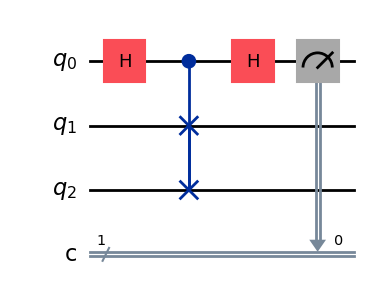

In [2]:
q = QuantumRegister(3,'q')
c = ClassicalRegister(1,'c')

qc = QuantumCircuit(q,c)
qc.h(q[0]) #Applying a Hadamard gate
#qc.x(q[1]) #Comment to make both states non-orthogonal
qc.cswap(q[0],q[1],q[2]) # Contolled SWAP gate
qc.h(q[0]) 
qc.measure(q[0],c[0])
qc.draw('mpl', filename='SWAPTest.png')

The circuit is initialised in 
$$
\ket{\Psi_{0}} = \ket{q_{0}q_{1}q_{2}} = \ket{0}\otimes\ket{q_{1}}\otimes\ket{q_{2}},
$$
for some one-qubit states $\ket{q_{1}}, \ket{q_{2}}$.
After the first layer, we have
$$
\ket{\Psi_{1}} = \left(\frac{\ket{0}+\ket{1}}{\sqrt{2}}\right)\otimes\ket{q_{1}}\otimes\ket{q_{2}}
 = \left(\frac{\ket{0}+\ket{1}}{\sqrt{2}}\right)\ket{q_{1}}\ket{q_{2}}.
$$
After the second layer, we obtain
$$
\ket{\Psi_{2}}
 = \frac{1}{\sqrt{2}}\Big(\ket{0}\ket{q_{1}}\ket{q_{2}}
+\ket{1}\ket{q_{2}}\ket{q_{1}}\Big),
$$
Applying the final Hadamard gate on the top qubit (layer 3), we obtain
\begin{align*}
\ket{\Psi_{3}}
& = \frac{1}{2}
\Big\{
\Big(\ket{0}+\ket{1}\Big)\ket{q_{1}}\ket{q_{2}}
+ \Big(\ket{0}-\ket{1}\Big)\ket{q_{2}}\ket{q_{1}}\Big\}\\
& = \frac{1}{2}
\ket{0}\Big(\ket{q_{1}}\ket{q_{2}} + \ket{q_{2}}\ket{q_{1}}\Big)
+ \frac{1}{2}\ket{1}\Big(\ket{q_{1}}\ket{q_{2}} -\ket{q_{2}}\ket{q_{1}}\Big)\Big\}.
\end{align*}

We now compute the probability of the top qubit being in position $'0'$.
When computing it via Born's rule, clearly the second term in $\ket{\Psi_{3}}$ (with $\ket{1}$) cancels, so that we are left with
\begin{align*}
\mathbb{P}('q_0=0')
 & = \bra{\Psi_{3}}\cdot\Big(\ket{0}\bra{0}\otimes \Ig\otimes \Ig \Big)\cdot \ket{\Psi_{3}} \\
& = \frac{1}{4}
\Big\{
\bra{0}\Big(\bra{q_{1}}\bra{q_{2}} + \bra{q_{2}}\bra{q_{1}}\Big)
\Big\}\cdot\Big(\ket{0}\bra{0}\otimes \Ig\otimes \Ig \Big)\cdot
\Big\{
\ket{0}\Big(\ket{q_{1}}\ket{q_{2}} + \ket{q_{2}}\ket{q_{1}}\Big)
\Big\}\\
 & = \frac{1}{4}
\Big(
\bra{q_{1}}\bra{q_{2}} + \bra{q_{2}}\bra{q_{1}}\Big)
\cdot
\Big(
\ket{q_{1}}\ket{q_{2}} + \ket{q_{2}}\ket{q_{1}}
\Big)\\
 & = \frac{1}{4}
\Big(2 + 2|\braket{q_{2}|q_{1}}|^2
\Big)
 = \frac{1}{2}
\Big(1 + |\braket{q_{2}|q_{1}}|^2
\Big).
\end{align*}

Therefore, from a simulation point of view, 
$$
|\langle q_1|q_2\rangle|^2 \approx 2\frac{\text{Number of "0"}}{\text{Number of shots}} - 1
$$


In [3]:
backend = Aer.get_backend('qasm_simulator')

nShots = 50000

results = backend.run(qc, shots=nShots).result()
plot_histogram(results.get_counts())

#job = bexecute(qc, backend, shots=nShots)
counts = results.get_counts()

In [4]:
squared_inner_prod = 2. * counts['0'] / nShots - 1.

print("Squared Inner Product:", squared_inner_prod)
print("Counts: ",counts)

Squared Inner Product: 1.0
Counts:  {'0': 50000}
